# AI-Powered Financial Fraud Detection & Risk Analytics System

## Notebook 1: Data Understanding & Exploratory Data Analysis (EDA)

### Objective
The purpose of this notebook is to understand the PaySim financial transaction dataset, analyze fraud patterns, identify business insights, and prepare the foundation for feature engineering and machine learning modeling.

Dataset: PaySim Mobile Money Fraud Dataset

Total Records: 6,362,620

Target Variable: isFraud

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [10]:
df = pd.read_csv("../data/raw/paysim.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 6362620
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [12]:
df.describe()
df.describe(include="object")

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


In [13]:
missing = df.isnull().sum()
missing[missing > 0]

if missing[missing > 0].size == 0:
    print("No Missing Values Found")

No Missing Values Found


In [14]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Fraud Distribution Analysis

In [15]:
fraud_counts = df["isFraud"].value_counts()

fraud_percentage = (
    df["isFraud"].value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


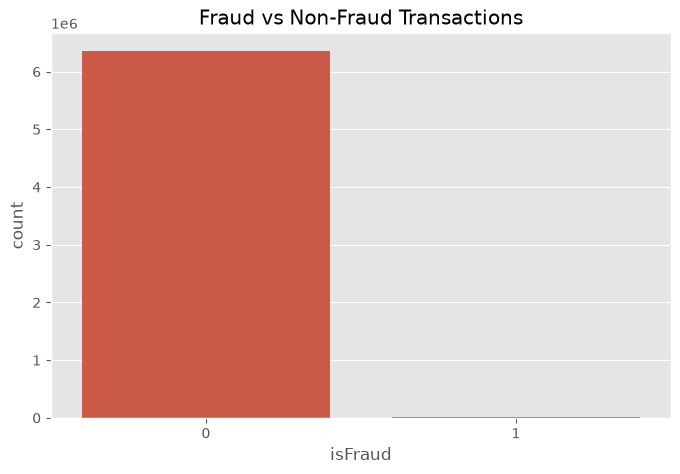

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="isFraud",
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.savefig("../reports/figures/fraud_vs_nonfraud.png", dpi=300, bbox_inches="tight")
plt.show()

## Transaction Type Analysis

In [17]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

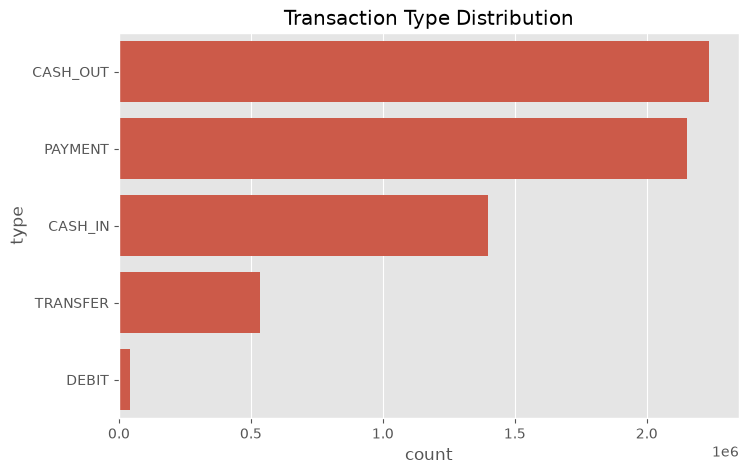

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="type",
    data=df,
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.savefig("../reports/figures/transaction_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Fraud by Transaction Type

fraud_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_type

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [20]:
fraud_percentage_type = (
    pd.crosstab(
        df["type"],
        df["isFraud"],
        normalize="index"
    ) * 100
)

fraud_percentage_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


### Observation

Fraud is concentrated mainly in:

- TRANSFER transactions
- CASH_OUT transactions

No fraud transactions are observed in:

- PAYMENT
- CASH_IN
- DEBIT

This indicates that fraudsters primarily move money through transfer and cash withdrawal operations.

In [21]:
# Transaction Amount Analysis

df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


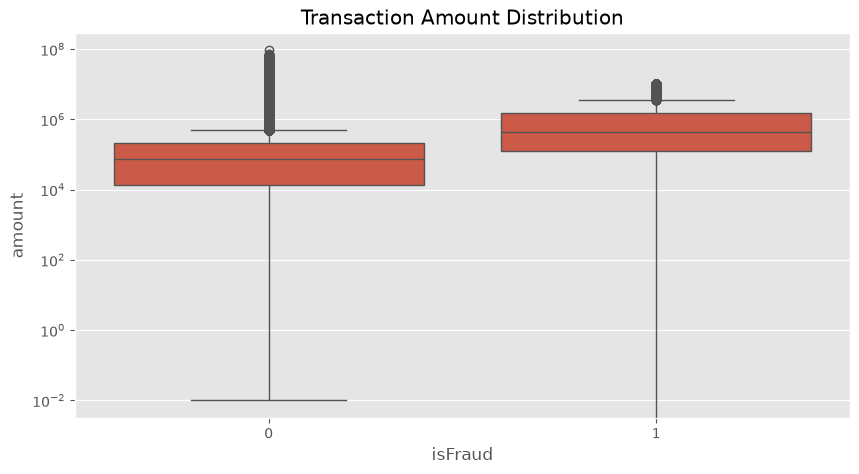

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=df
)

plt.yscale("log")
plt.title("Transaction Amount Distribution")
plt.savefig("../reports/figures/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# Correlation Analysis

numeric_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

corr_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


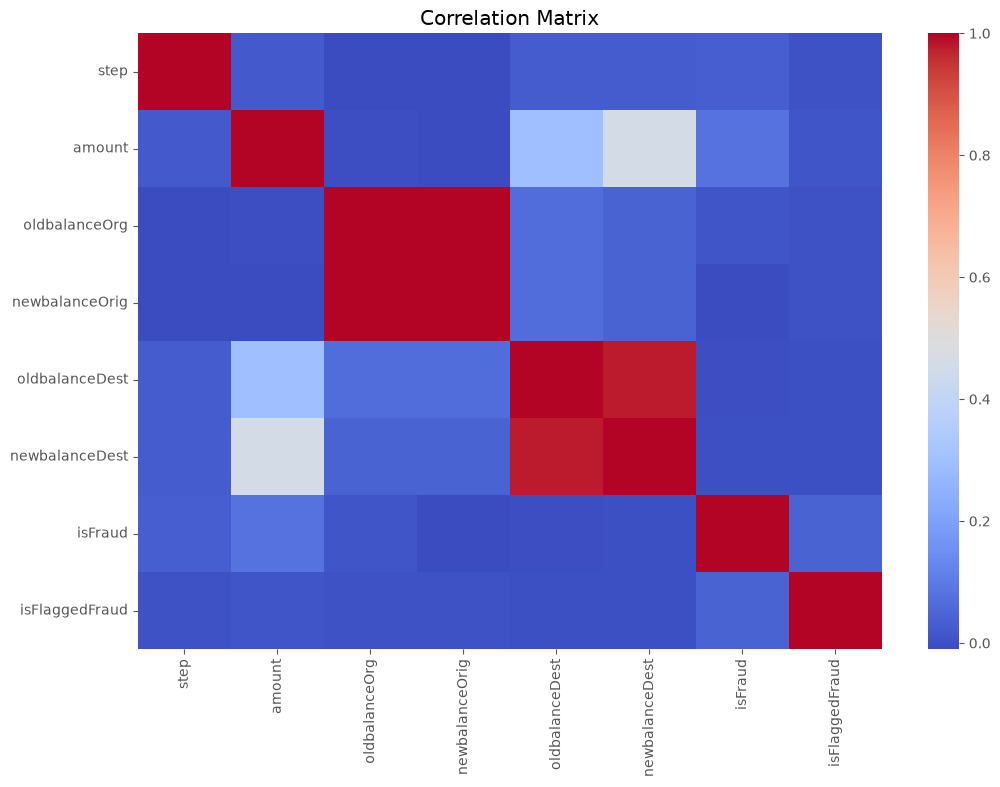

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)
plt.savefig("../reports/figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Fraud Correlation Analysis

corr_matrix["isFraud"]\
.sort_values(
    ascending=False
)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

# Key Business Insights

### 1. Fraud Rate

Only 0.129% of all transactions are fraudulent.

This indicates a highly imbalanced dataset.

---

### 2. High Risk Transaction Types

TRANSFER and CASH_OUT transactions contribute to nearly all fraud cases.

---

### 3. Fraud Amounts

Fraudulent transactions generally involve larger amounts compared to normal transactions.

---

### 4. Class Imbalance

The dataset contains extremely few fraud transactions compared to genuine transactions.

Advanced balancing techniques will be required before model training.

---

### 5. Feature Engineering Opportunity

Current variables alone may not be sufficient.

Derived features such as:

- Balance Error
- Transaction Velocity
- Hour of Transaction
- Risk Score

can significantly improve fraud detection performance.

In [26]:
eda_summary = {
    "total_rows": len(df),
    "total_columns": len(df.columns),
    "fraud_cases": df["isFraud"].sum(),
    "fraud_percentage":
        round(
            df["isFraud"].mean()*100,
            4
        )
}

pd.DataFrame(
    [eda_summary]
).to_csv(
    "../reports/eda/eda_summary.csv",
    index=False
)

print("EDA Summary Saved")

EDA Summary Saved
